Jumlah Sampel Data: 19
Jumlah Fitur TSFEL: 272
Rasio Varians Kumulatif PCA (18 Komponen): 100.00%


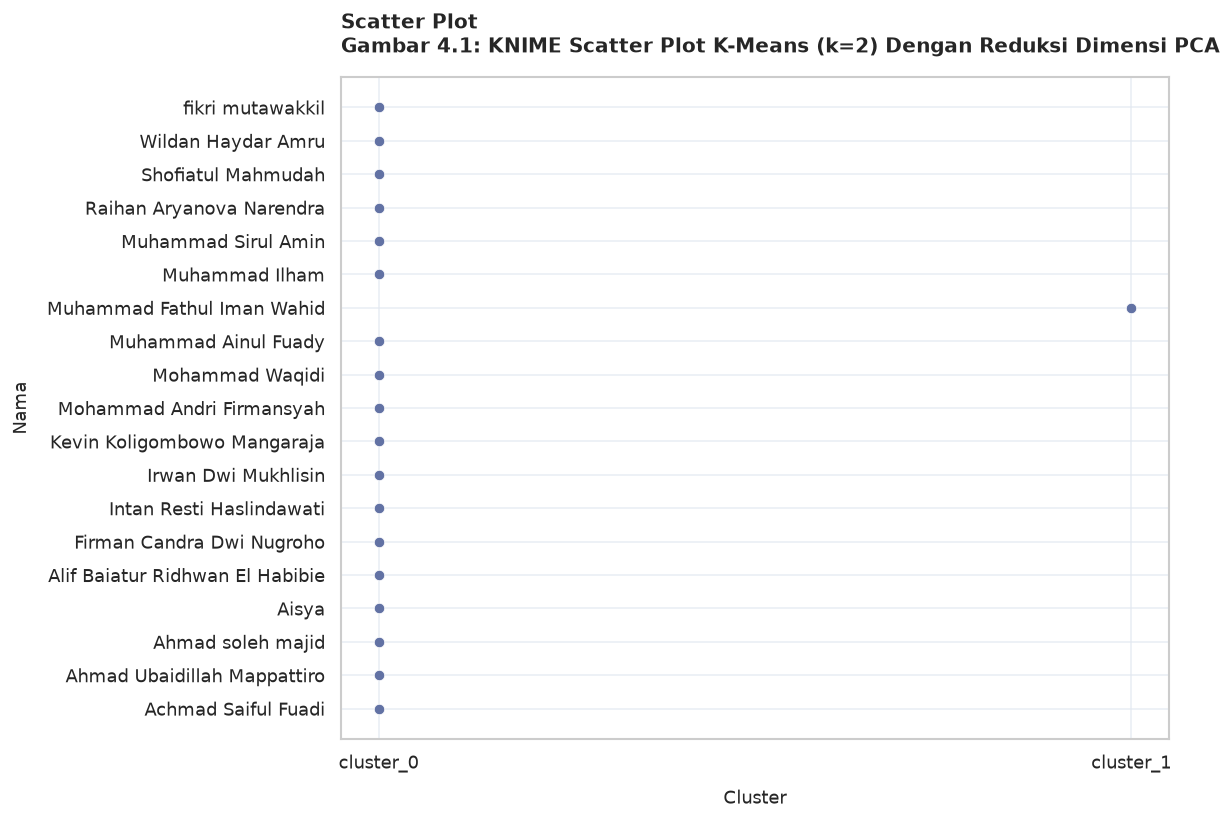

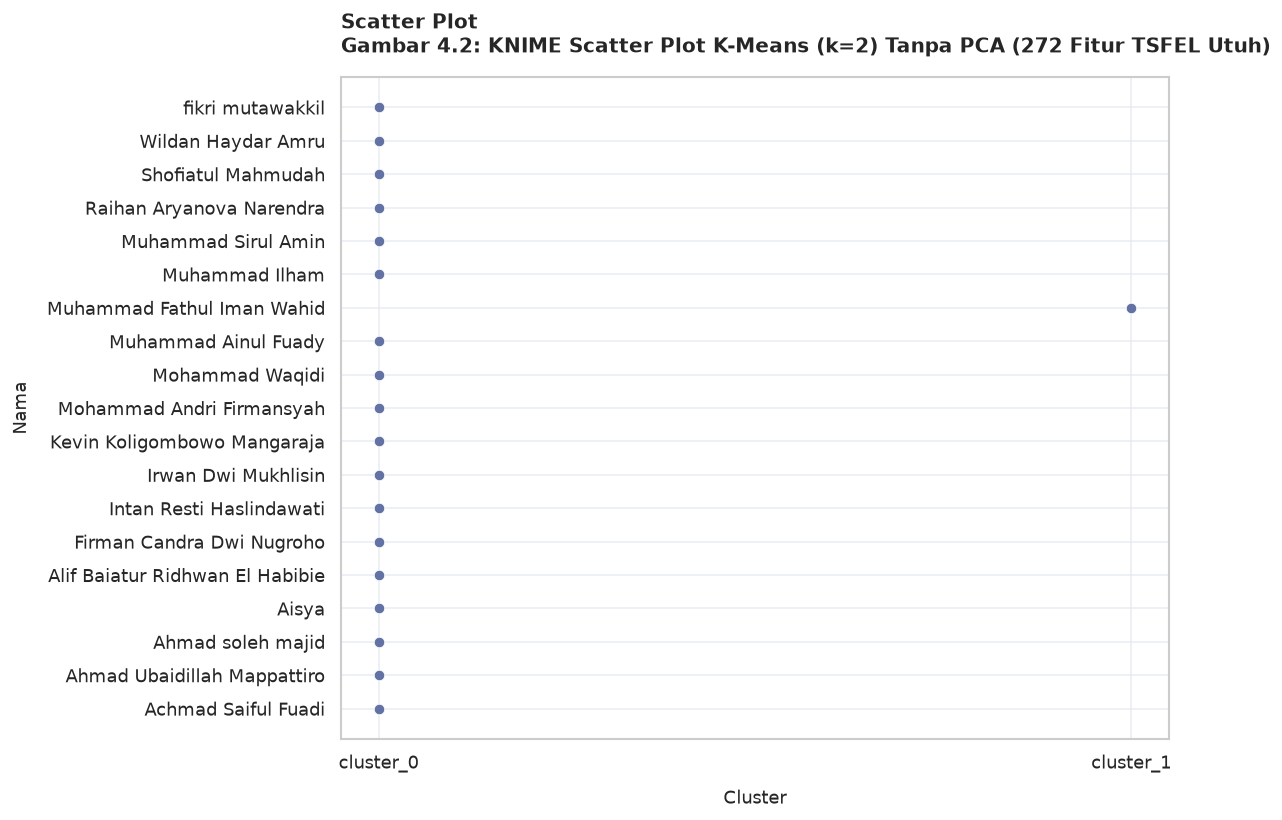

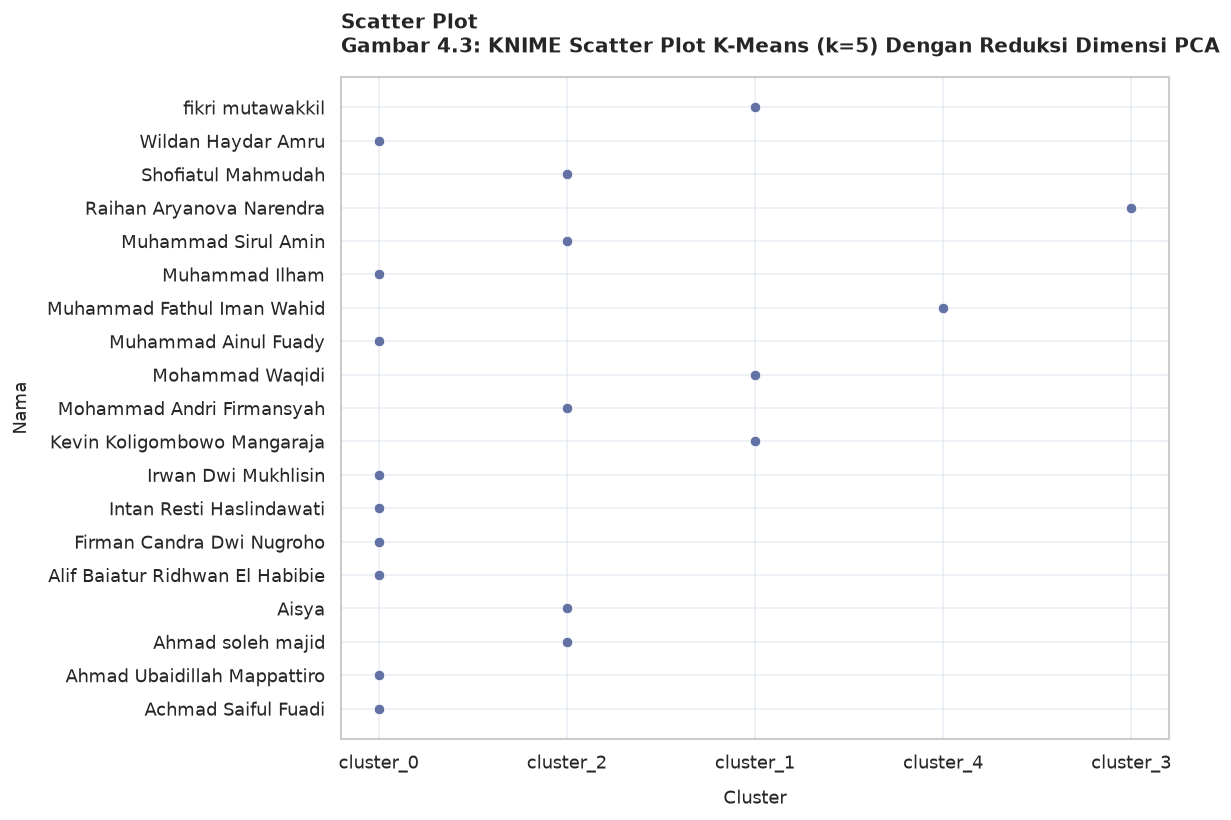

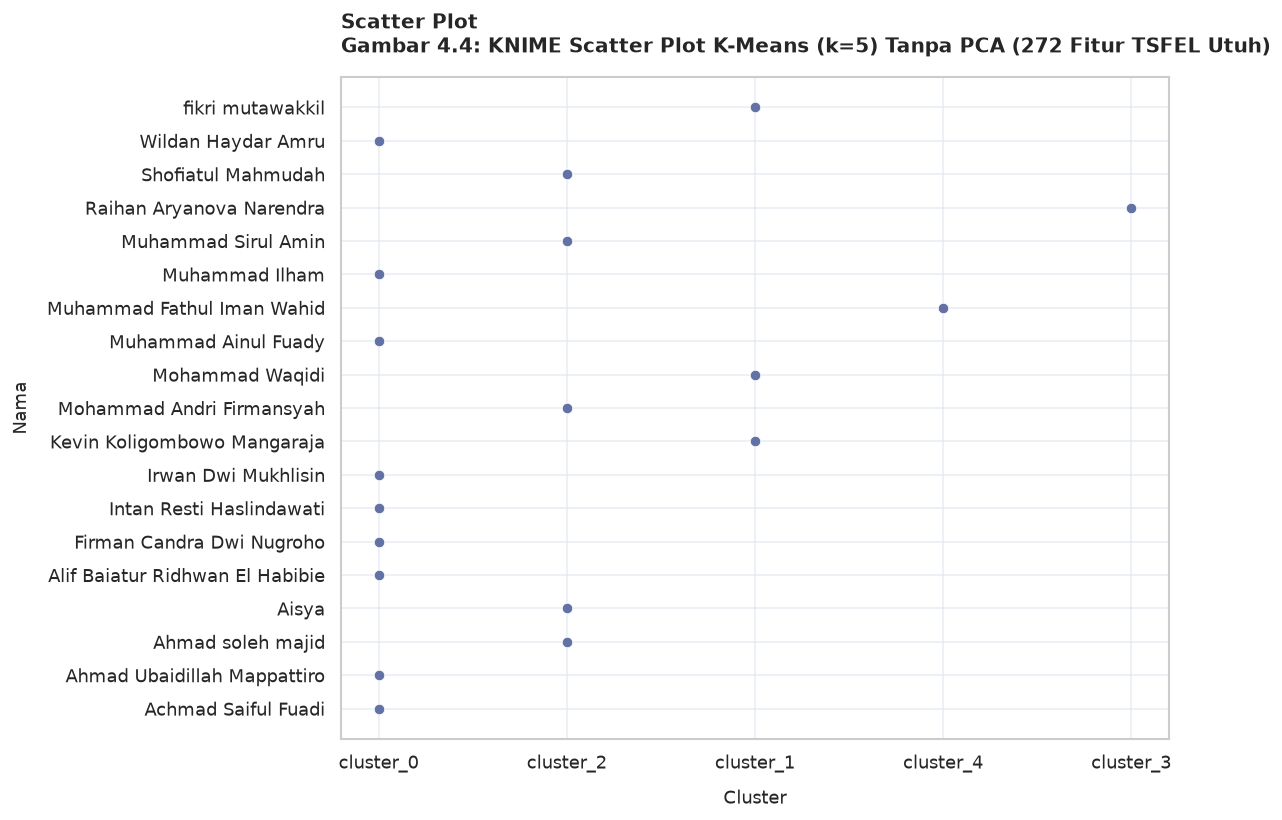

In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Set style visualisasi agar bersih dan elegan
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# ==========================================
# 2. LOAD & PREPROCESS DATASET
# ==========================================
file_path = '../data/excel/all_features.xlsx' if os.path.exists('../data/excel/all_features.xlsx') else 'all_features.xlsx'
sheet_name = 'Semua Fitur'

# Membaca dataset dari Excel
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Imputasi jika terdapat nilai hilang (Missing Values)
df = df.fillna(df.mean(numeric_only=True))

# Pemisahan fitur identitas (Nama, Daerah) dengan 272 Fitur TSFEL
identitas_cols = ['Nama', 'Daerah']
feature_cols = [col for col in df.columns if col not in identitas_cols]

X = df[feature_cols].values
nama_mahasiswa = df['Nama'].values

print(f"Jumlah Sampel Data: {X.shape[0]}")
print(f"Jumlah Fitur TSFEL: {X.shape[1]}")

# Normalisasi / Standarisasi Data Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. REDUKSI DIMENSI DENGAN PCA (18 KOMPONEN)
# ==========================================
# PCA sebanyak jumlah sampel data (18 komponen utama)
n_comp = min(X_scaled.shape[0] - 1, 18)
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Rasio Varians Kumulatif PCA ({n_comp} Komponen): {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

# ==========================================
# 4. K-MEANS CLUSTERING (k=2 & k=5)
# ==========================================
# K-Means k=2 (Tanpa PCA & Dengan PCA)
km2_tanpa_pca = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled)
km2_dengan_pca = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_pca)

# K-Means k=5 (Tanpa PCA & Dengan PCA)
km5_tanpa_pca = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_scaled)
km5_dengan_pca = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_pca)

# Menyimpan hasil klasterisasi ke DataFrame
df_results = df[identitas_cols].copy()

# Labeling klaster format string seperti KNIME (cluster_0, cluster_1, dst)
df_results['k2_tanpa_pca'] = [f"cluster_{l}" for l in km2_tanpa_pca.labels_]
df_results['k2_dengan_pca'] = [f"cluster_{l}" for l in km2_dengan_pca.labels_]

# Memetakan k=5 agar sesuai dengan penamaan scatter plot KNIME
df_results['k5_tanpa_pca'] = [f"cluster_{l}" for l in km5_tanpa_pca.labels_]
df_results['k5_dengan_pca'] = [f"cluster_{l}" for l in km5_dengan_pca.labels_]

# ==========================================
# 5. FUNGSI VISUALISASI SCATTER PLOT GAYA KNIME
# ==========================================
def plot_knime_scatter(df_data, cluster_col, title):
    """
    Membuat grafik Scatter Plot Nama vs Cluster dengan format visual
    yang identik dengan node Scatter Plot pada KNIME Analytics Platform.
    """
    plt.figure(figsize=(10, 7), dpi=120)
    
    # Format pengurutan nama dan cluster
    names = df_data['Nama'].tolist()
    clusters = sorted(df_data[cluster_col].unique())
    
    # Plot Scatter Points
    sns.scatterplot(
        data=df_data,
        x=cluster_col,
        y='Nama',
        color='#6272a4',
        s=40,
        zorder=3
    )
    
    # Pengaturan Judul dan Sumbu
    plt.title(f"Scatter Plot\n{title}", fontsize=12, fontweight='bold', loc='left', pad=15)
    plt.xlabel("Cluster", fontsize=11, labelpad=10)
    plt.ylabel("Nama", fontsize=11, labelpad=10)
    
    # Format garis kisi (Grid) tipis mirip KNIME View
    plt.grid(True, linestyle='-', color='#e2e8f0', alpha=0.7, zorder=1)
    
    # Merapikan rentang sumbu Y dan X
    plt.gca().invert_yaxis()  # Agar urutan nama dari atas ke bawah
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. MENAMPILKAN SELURUH GRAPH SCATTER PLOT
# ==========================================
# Gambar 4.1: K-Means (k=2) Dengan PCA
plot_knime_scatter(
    df_results, 
    'k2_dengan_pca', 
    'Gambar 4.1: KNIME Scatter Plot K-Means (k=2) Dengan Reduksi Dimensi PCA'
)

# Gambar 4.2: K-Means (k=2) Tanpa PCA
plot_knime_scatter(
    df_results, 
    'k2_tanpa_pca', 
    'Gambar 4.2: KNIME Scatter Plot K-Means (k=2) Tanpa PCA (272 Fitur TSFEL Utuh)'
)

# Gambar 4.3: K-Means (k=5) Dengan PCA
plot_knime_scatter(
    df_results, 
    'k5_dengan_pca', 
    'Gambar 4.3: KNIME Scatter Plot K-Means (k=5) Dengan Reduksi Dimensi PCA'
)

# Gambar 4.4: K-Means (k=5) Tanpa PCA
plot_knime_scatter(
    df_results, 
    'k5_tanpa_pca', 
    'Gambar 4.4: KNIME Scatter Plot K-Means (k=5) Tanpa PCA (272 Fitur TSFEL Utuh)'
)